## **Caso 11: Predicción de baja productividad (Stacking + SHAP)**

En este caso desarrollamos un **modelo de Machine Learning para identificar empleados con riesgo de baja productividad**, combinando múltiples algoritmos mediante una técnica de *stacking*.

El **objetivo** no es solo predecir el rendimiento actual, sino **anticipar posibles situaciones de bajo desempeño a partir de variables como engagement, salario relativo, desempeño histórico o contexto organizativo.**

Además, **incorporamos técnicas de interpretabilidad (SHAP)** para entender qué factores están influyendo en las predicciones, permitiendo **trasladar el modelo a decisiones reales de negocio**.

Este enfoque **permite a la organización actuar de forma proactiva**, diseñando *acciones específicas como planes de desarrollo, ajustes organizativos o intervenciones sobre managers y equipos.*

In [1]:
# Importación de librerias

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

!pip install catboost
from catboost import CatBoostClassifier

# Metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Interpretabilidad
import shap

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Opcional: silenciar warnings
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
# Cargamos el dataset y lo pre-visualizamos

# Ruta del archivo (ajusta si es necesario)
url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-case-11-low-productivity-risk-prediction/main/people_analytics_case11_dataset.csv"

# Cargar dataset
employees = pd.read_csv(url)

# Vista inicial

print("Shape:", employees.shape)
employees.head(10)

Shape: (824, 19)


,employee_id,age,gender,department,job_level,tenure,manager_id,salary,salary_position_pct,performance_score,manager_score,absenteeism_days,training_hours,promotion_last_2y,internal_mobility,workload_index,team_size,remote_ratio,low_performance_risk
0,1,50,Female,Marketing,Mid,11.2,92,29478,0.35,2,2.0,5,22.0,1,0,65,4,0.75,1
1,2,36,Female,Finance,Junior,5.3,76,33210,0.39,5,5.0,2,37.0,0,0,83,5,0.23,0
2,3,29,Female,Finance,Mid,0.8,38,35922,0.09,3,4.0,2,43.0,0,0,65,13,0.33,1
3,4,42,Male,HR,Mid,2.9,36,61289,0.51,2,3.0,6,66.0,0,0,98,14,0.04,1
4,5,40,Female,Finance,Senior,4.8,41,88561,0.55,1,3.0,5,61.0,1,0,68,12,0.83,1
5,6,44,Male,Data,Mid,0.4,69,58340,0.54,2,4.0,4,11.0,0,1,99,13,0.85,1
6,7,32,Female,HR,Junior,10.7,13,64850,0.68,1,3.0,4,29.0,0,0,33,8,0.63,1
7,8,32,Male,Data,Senior,8.1,87,81984,0.29,5,2.0,2,64.0,0,0,94,3,0.35,1
8,9,45,Female,IT,Lead,3.5,58,63163,0.56,2,2.0,4,40.0,0,0,69,4,0.08,1
9,10,57,Male,Data,Senior,17.1,50,73175,0.83,5,4.0,6,19.0,0,0,66,10,0.75,0


**EDA PRELIMINAR**

In [ ]:
# Vemos estadísticas báiscas con describe

employees.describe()

,employee_id,age,tenure,manager_id,salary,salary_position_pct,performance_score,manager_score,absenteeism_days,training_hours,promotion_last_2y,internal_mobility,workload_index,team_size,remote_ratio,low_performance_risk
count,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,792.000000,824.000000,792.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000
mean,401.922330,40.913835,4.946117,50.484223,57160.209951,0.505413,2.983010,3.143939,5.004854,38.962121,0.303398,0.231796,64.643204,8.606796,0.507767,0.701456
std,230.898375,11.111108,4.853971,27.777229,18553.308472,0.223858,1.434585,1.407758,2.268164,22.568364,0.460005,0.422236,20.163159,3.550812,0.280437,0.457897
min,1.000000,22.000000,0.000000,1.000000,25191.000000,0.010000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,3.000000,0.000000,0.000000
25%,202.750000,31.000000,1.600000,27.000000,41210.250000,0.340000,2.000000,2.000000,3.000000,20.000000,0.000000,0.000000,47.000000,5.000000,0.270000,0.000000
50%,402.500000,42.000000,3.400000,51.000000,56938.500000,0.520000,3.000000,3.000000,5.000000,39.000000,0.000000,0.000000,65.500000,9.000000,0.510000,1.000000
75%,603.250000,50.000000,7.000000,74.000000,73365.750000,0.680000,4.000000,4.000000,6.000000,58.000000,1.000000,0.000000,82.000000,12.000000,0.740000,1.000000
max,800.000000,59.000000,30.600000,99.000000,89871.000000,0.990000,5.000000,5.000000,16.000000,79.000000,1.000000,1.000000,99.000000,14.000000,1.000000,1.000000


In [ ]:
# Vemos tipos de datos con info

employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           824 non-null    int64  
 1   age                   824 non-null    int64  
 2   gender                824 non-null    object 
 3   department            824 non-null    object 
 4   job_level             824 non-null    object 
 5   tenure                824 non-null    float64
 6   manager_id            824 non-null    int64  
 7   salary                824 non-null    int64  
 8   salary_position_pct   824 non-null    float64
 9   performance_score     824 non-null    int64  
 10  manager_score         792 non-null    float64
 11  absenteeism_days      824 non-null    int64  
 12  training_hours        792 non-null    float64
 13  promotion_last_2y     824 non-null    int64  
 14  internal_mobility     824 non-null    int64  
 15  workload_index        8

In [ ]:
# Revisamos valores nulos

employees.isnull().sum()

,0
employee_id,0
age,0
gender,0
department,0
job_level,0
tenure,0
manager_id,0
salary,0
salary_position_pct,0
performance_score,0


In [ ]:
# Gestión de nulos

# En este paso tratamos los valores nulos detectados en:
# - manager_score
# - training_hours
#
# La imputación se hace con lógica de negocio, no solo técnica.

# 1. manager_score → imputación por mediana del departamento

# La calidad del manager suele estar influenciada por dinámicas de equipo / departamento.
# Imputar la mediana global podría distorsionar esa realidad.
# Por eso usamos la mediana dentro de cada departamento.

employees["manager_score"] = employees.groupby("department")["manager_score"]\
    .transform(lambda x: x.fillna(x.median()))

# 2. training_hours → imputación a 0

# En muchos casos reales, ausencia de datos en formación suele significar:
# → no ha realizado formación
# Por tanto, imputamos a 0 en lugar de usar media o mediana.

employees["training_hours"] = employees["training_hours"].fillna(0)


# Revisión
print("Nulos después de imputación:")
print(employees[["manager_score", "training_hours"]].isnull().sum())

Nulos después de imputación:
manager_score     0
training_hours    0
dtype: int64


In [ ]:
# Revisamos duplicados

employees.duplicated().sum()

np.int64(24)

In [ ]:
# Los eliminamos

employees.drop_duplicates(inplace=True)

# Revisamos

employees.duplicated().sum()

np.int64(0)

**Visualización de Variables y sus relaciones:**

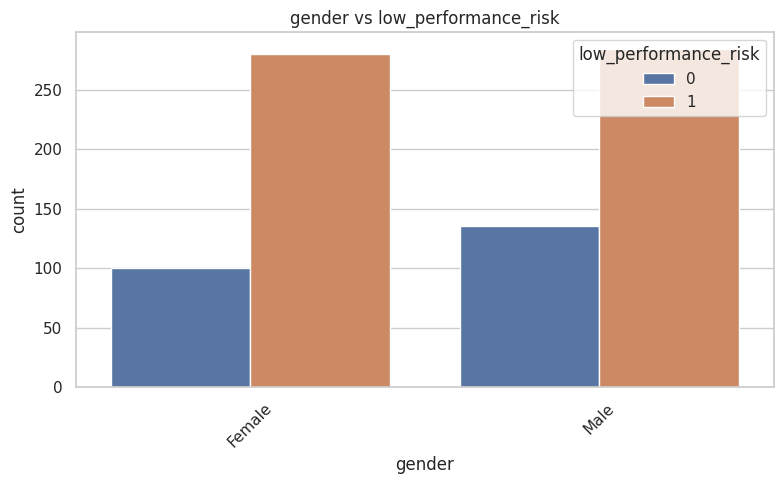

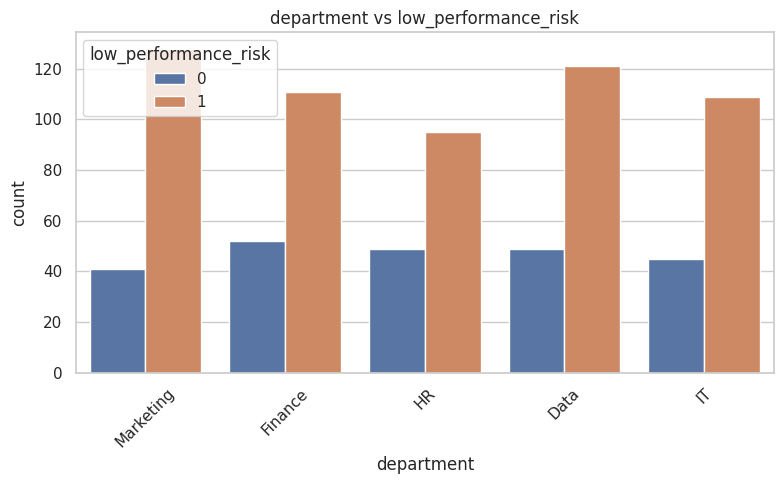

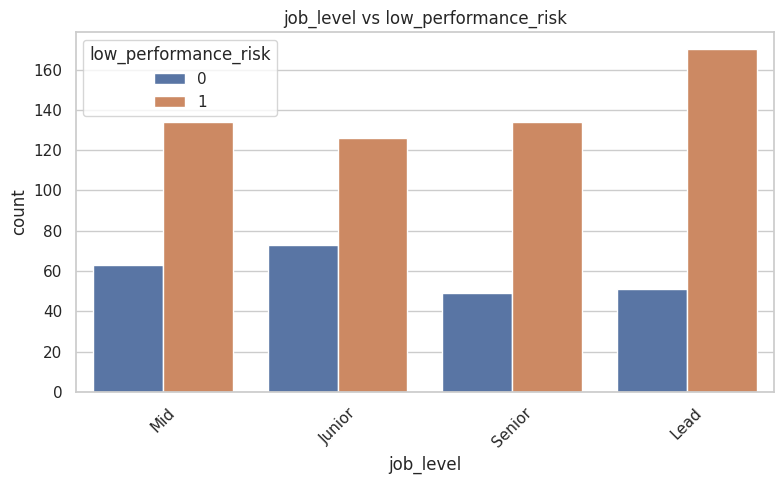

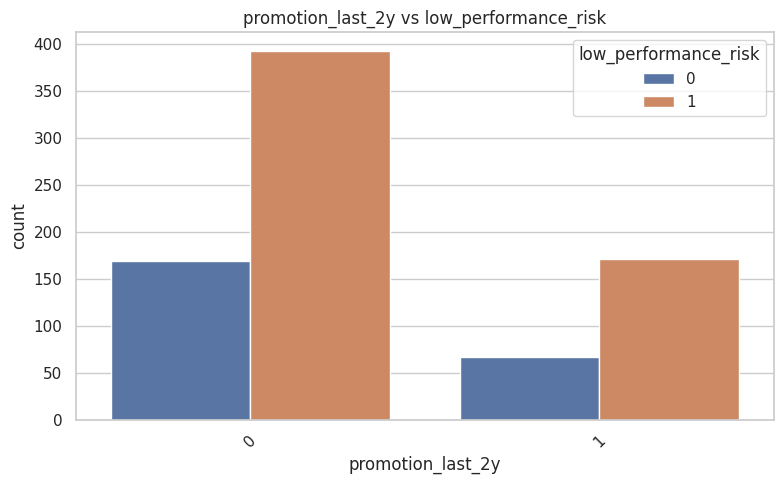

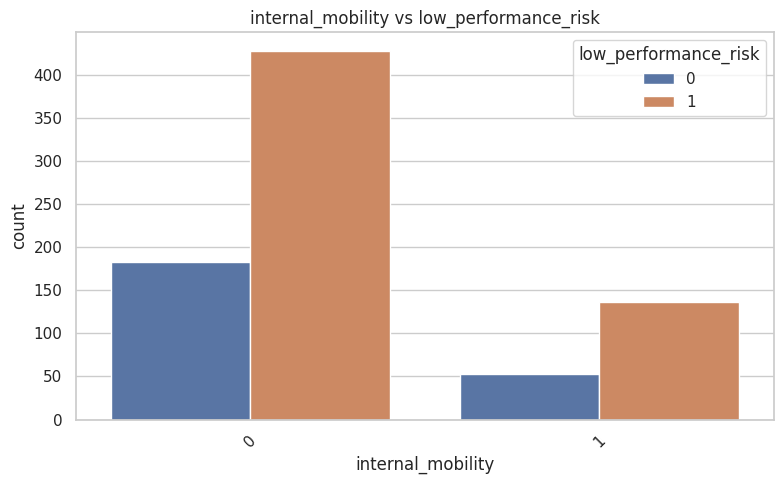

In [ ]:
# Variables Categóricas VS Target

# En esta celda analizamos cómo se distribuye el target
# (low_performance_risk) dentro de cada variable categórica.

# Esto nos permite detectar patrones visibles de riesgo
# según departamento, nivel, género, promociones, etc.

categorical_cols = [
    "gender",
    "department",
    "job_level",
    "promotion_last_2y",
    "internal_mobility"
]

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=employees, x=col, hue="low_performance_risk")
    plt.title(f"{col} vs low_performance_risk")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

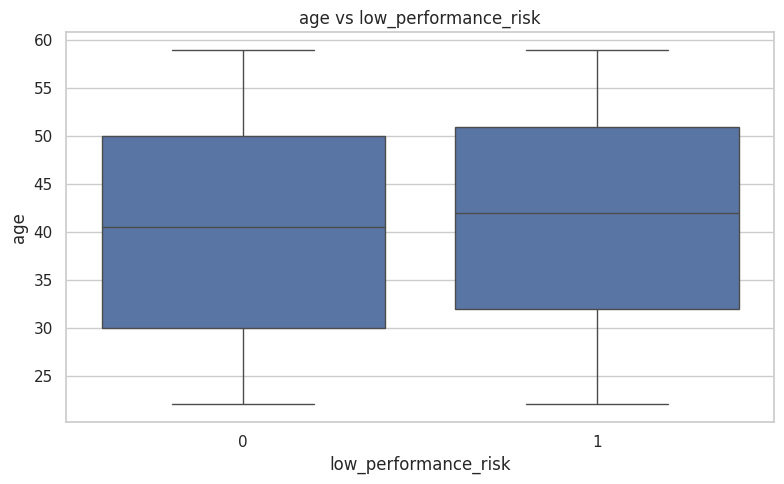

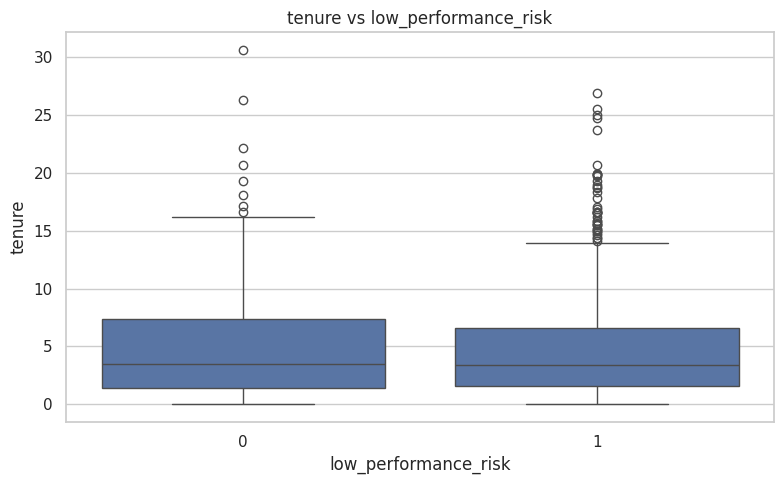

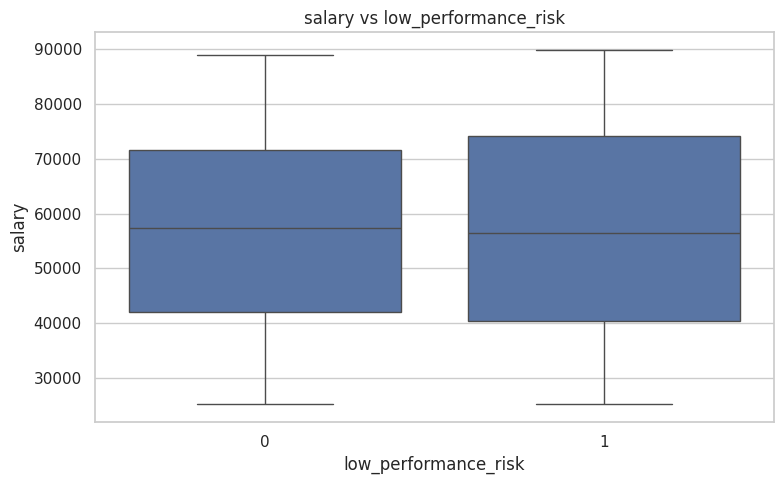

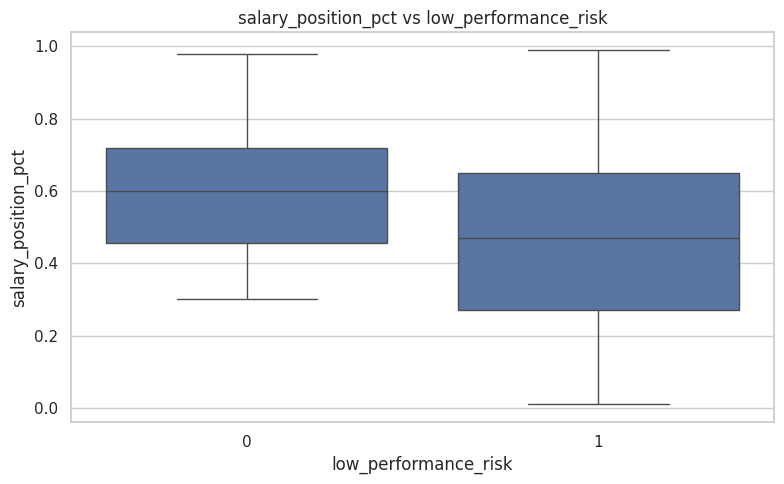

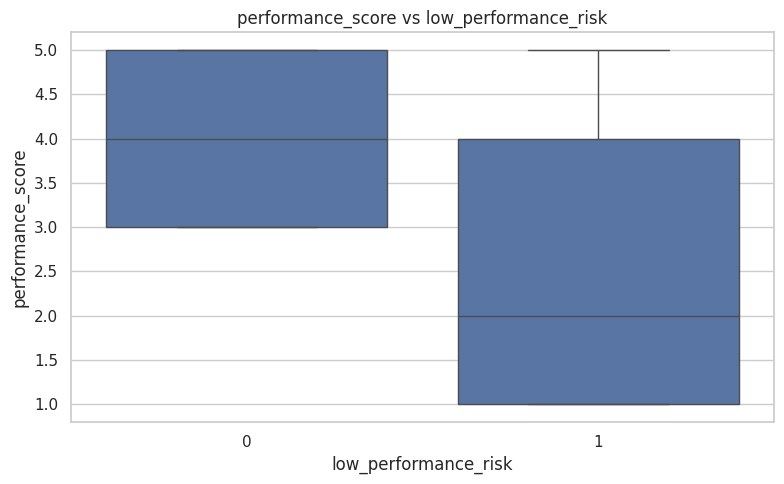

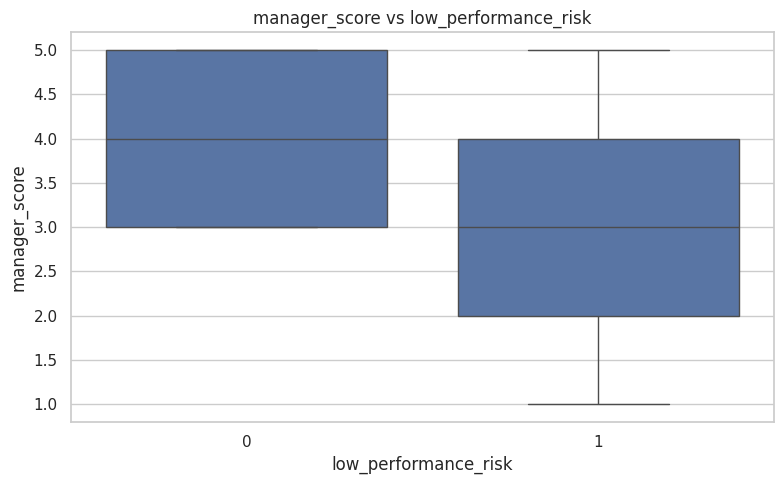

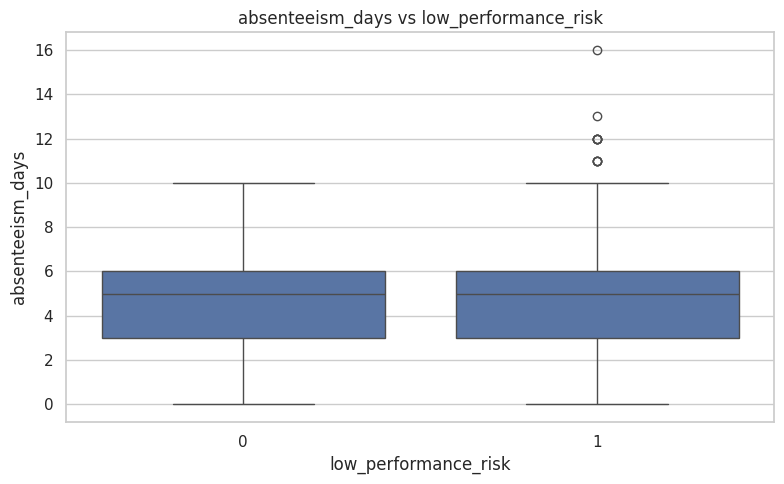

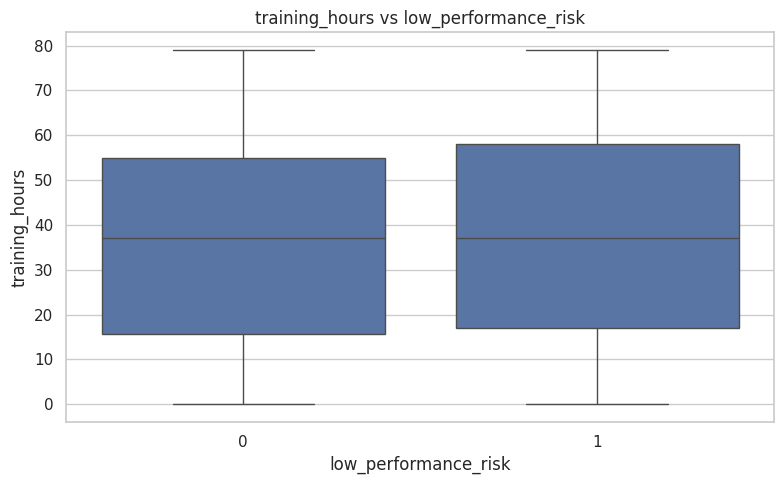

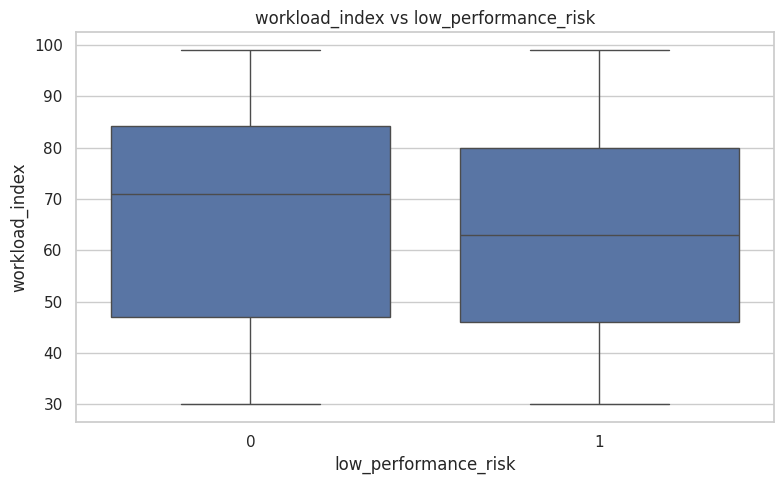

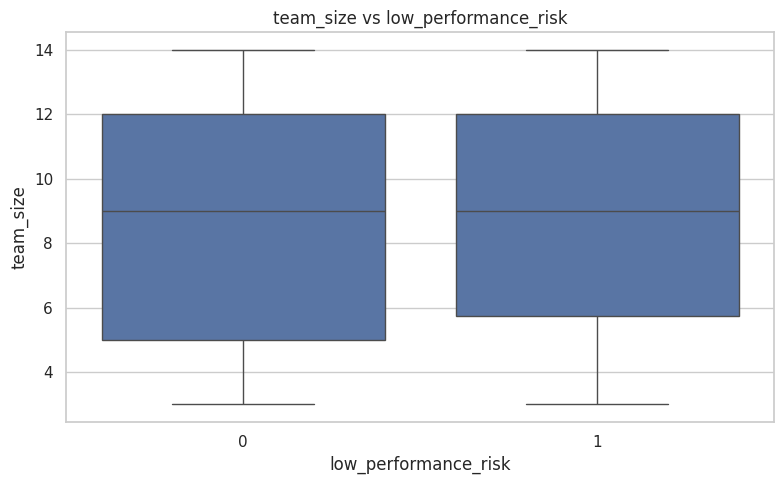

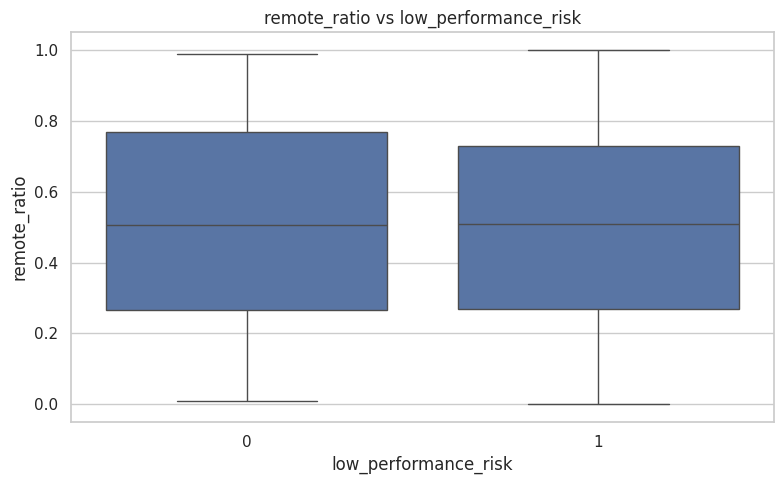

In [ ]:
# Variables Numéricas Vs Target

# En esta celda analizamos la distribución de las variables numéricas
# según el target. Para ello usamos boxplots, que permiten ver:
# - mediana
# - dispersión
# - posibles outliers

# Esto ayuda a identificar qué variables parecen tener
# mayor capacidad explicativa sobre el riesgo de baja productividad.

numerical_cols = [
    "age",
    "tenure",
    "salary",
    "salary_position_pct",
    "performance_score",
    "manager_score",
    "absenteeism_days",
    "training_hours",
    "workload_index",
    "team_size",
    "remote_ratio"
]

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=employees, x="low_performance_risk", y=col)
    plt.title(f"{col} vs low_performance_risk")
    plt.tight_layout()
    plt.show()

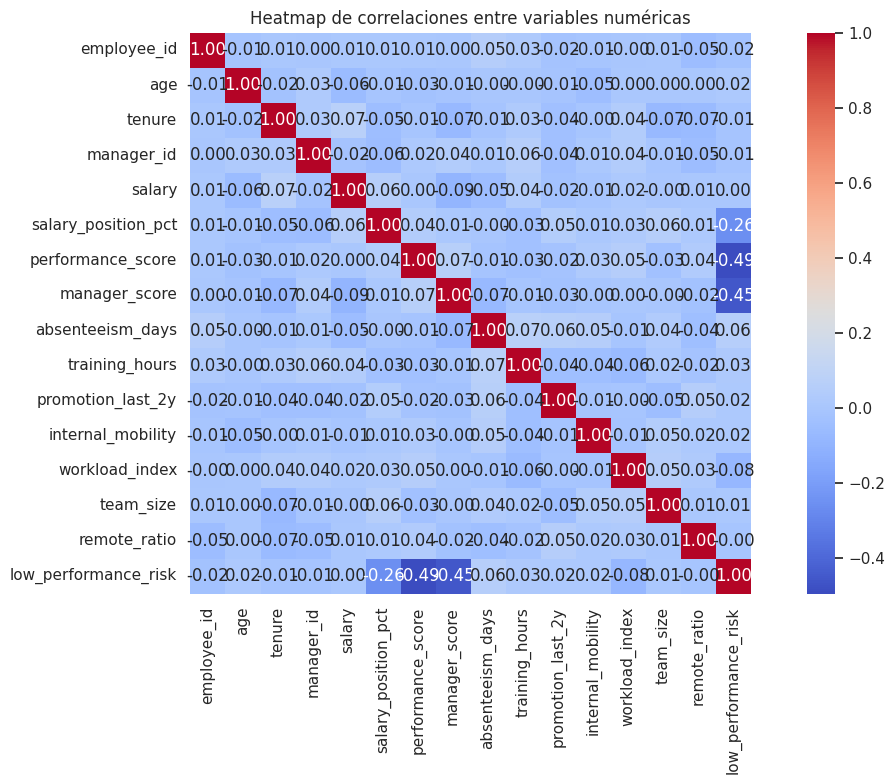

In [ ]:
# Heatmap de correlaciones

# En esta celda analizamos la relación entre variables numéricas
# mediante una matriz de correlación.

# El objetivo es detectar:
# - variables con alta relación entre sí
# - posibles patrones asociados al target
# - señales de multicolinealidad

# Seleccionamos solo variables numéricas
numeric_data = employees.select_dtypes(include=["int64", "float64"]).copy()

# Calculamos correlaciones
corr_matrix = numeric_data.corr()

# Visualización
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

## **Insights clave del EDA preliminar**

1) **El riesgo de baja productividad no es aleatorio**, sino que está **asociado a varios factores organizativos y de contexto.**

2) A nivel organizativo, se observa una **mayor concentración de riesgo en departamentos como Data y Marketing**, así como en **posiciones de mayor responsabilidad**, especialmente en niveles Lead.

3) En cuanto al desarrollo profesional, **los empleados sin promoción reciente o sin movilidad interna presentan un mayor riesgo**, lo que sugiere posibles situaciones de estancamiento o falta de crecimiento.

4) Desde el punto de vista de condiciones laborales, **el posicionamiento salarial relativo también influye**: los empleados con salarios menos competitivos tienden a mostrar mayor riesgo de bajo rendimiento.

5) Además, **variables como el performance score y el manager score tienen una relación clara con el target**, lo que refuerza la importancia del desempeño previo y, especialmente, del rol del manager en la productividad.

En conjunto, estos resultados apuntan a que *la baja productividad está más relacionada con factores estructurales (liderazgo, desarrollo y contexto organizativo) que con elementos puramente individuales.*

Distribución absoluta del target:
low_performance_risk
0    236
1    564
Name: count, dtype: int64

Distribución porcentual del target:
low_performance_risk
0    29.5
1    70.5
Name: proportion, dtype: float64


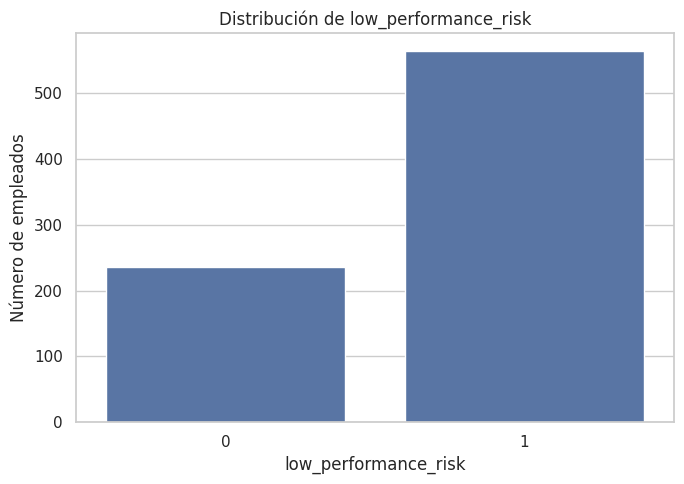

In [ ]:
# Balanceo del Target

target_counts = employees["low_performance_risk"].value_counts().sort_index()
target_pct = employees["low_performance_risk"].value_counts(normalize=True).sort_index() * 100

print("Distribución absoluta del target:")
print(target_counts)
print("\nDistribución porcentual del target:")
print(target_pct.round(2))

plt.figure(figsize=(7, 5))
sns.countplot(data=employees, x="low_performance_risk")
plt.title("Distribución de low_performance_risk")
plt.xlabel("low_performance_risk")
plt.ylabel("Número de empleados")
plt.tight_layout()
plt.show()

## **Modelado predictivo: comparación de algoritmos y explicabilidad**

En esta fase desarrollamos un **modelo predictivo para identificar empleados con riesgo de baja productividad.**

Para ello, *se entrenan y comparan distintos algoritmos de Machine Learning* ampliamente utilizados en problemas tabulares: **Random Forest, XGBoost, LightGBM y CatBoost**. El objetivo es evaluar su rendimiento y seleccionar el modelo más robusto.

Posteriormente, se construye un modelo de *stacking* que combina los anteriores **texto en negrita**, buscando mejorar la capacidad predictiva mediante el uso conjunto de múltiples modelos.


In [ ]:
# Preparamos dataset para el Modelado

# En esta celda preparamos los datos para el entrenamiento:
# - Definimos variables predictoras (X) y target (y)
# - Separamos train y test
# - Creamos pipeline de preprocesado (numéricas + categóricas)

# Definición de X e y

X = employees.drop(columns=["low_performance_risk", "employee_id"])
y = employees["low_performance_risk"]

# Separación train / test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Usamos stratify para evitar problemas por estar el target desbalanceado




In [ ]:
# Identificación de variables

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [ ]:
# Preprocesado (por robustez y precaución)

# Aunque el dataset ya está limpio, mantenemos la imputación en el pipeline
# para garantizar robustez y evitar errores en escenarios reales.

# Numéricas:
# - imputación por mediana
# - escalado
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas:
# - imputación (más frecuente)
# - one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [ ]:
# 5. Check final

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Variables numéricas:", len(numerical_cols))
print("Variables categóricas:", len(categorical_cols))

Train shape: (640, 17)
Test shape: (160, 17)
Variables numéricas: 14
Variables categóricas: 3


**Entrenamiento de Modelos:**


🔍 Modelo: RandomForest

📊 Métricas:
Accuracy:  0.988
Precision: 0.991
Recall:    0.991
F1-score:  0.991
ROC-AUC:   1.000

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.99      0.99      0.99       113

    accuracy                           0.99       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.99      0.99      0.99       160



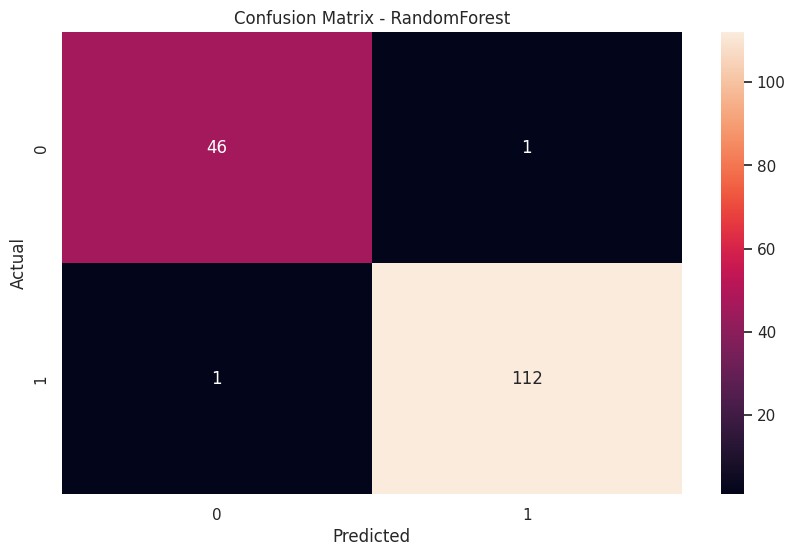


🔍 Modelo: XGBoost

📊 Métricas:
Accuracy:  0.994
Precision: 1.000
Recall:    0.991
F1-score:  0.996
ROC-AUC:   0.997

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.99      1.00       113

    accuracy                           0.99       160
   macro avg       0.99      1.00      0.99       160
weighted avg       0.99      0.99      0.99       160



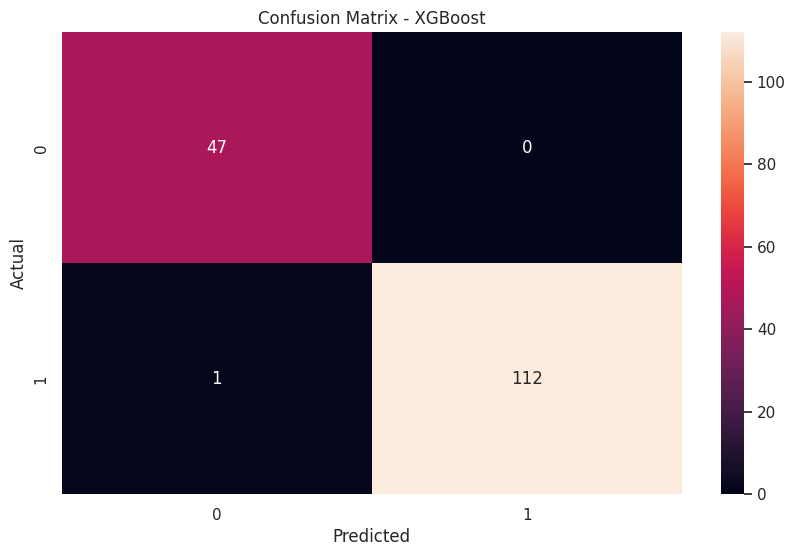


🔍 Modelo: LightGBM
[LightGBM] [Info] Number of positive: 451, number of negative: 189
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.704688 -> initscore=0.869720
[LightGBM] [Info] Start training from score 0.869720
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

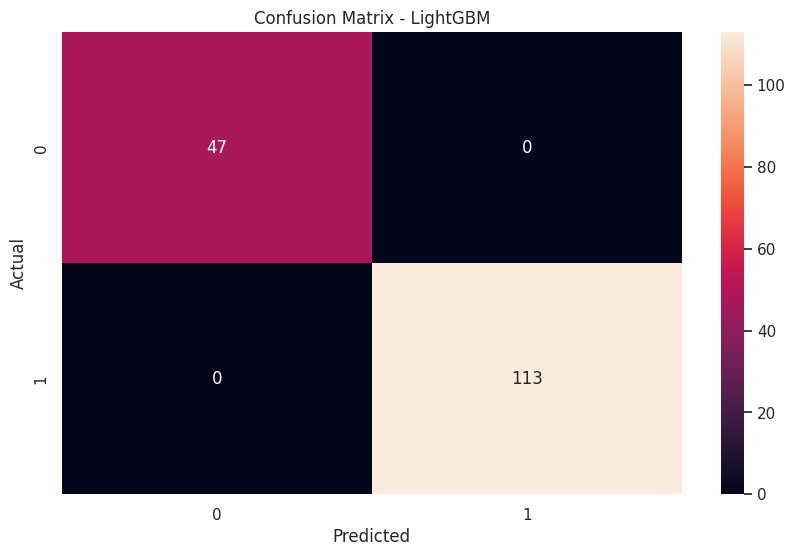


🔍 Modelo: CatBoost

📊 Métricas:
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-score:  1.000
ROC-AUC:   1.000

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00       113

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



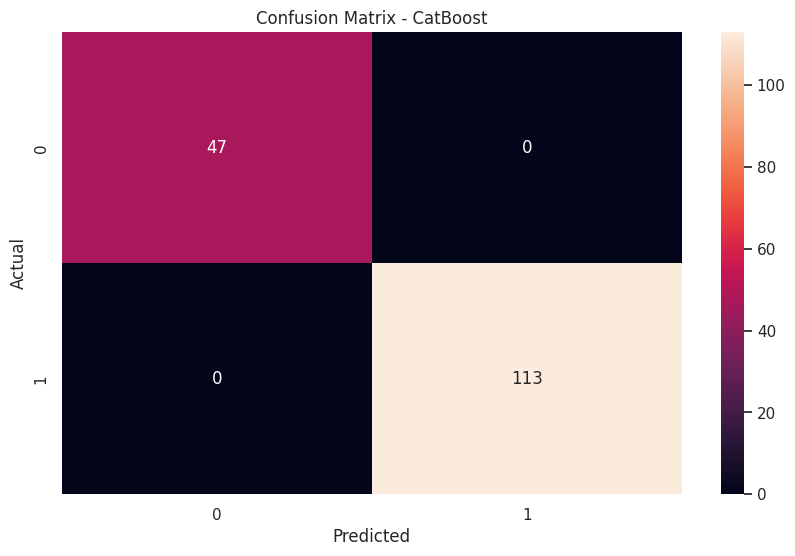

In [ ]:
results = []

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

for name, model in models.items():

    print(f"\n==============================")
    print(f"🔍 Modelo: {name}")
    print(f"==============================")

# Pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

# Entrenamiento
    pipe.fit(X_train, y_train)

# Predicciones
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

# Métricas

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print("\n📊 Métricas:")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"ROC-AUC:   {roc_auc:.3f}")

# Informe de Clasificación

    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred))

# Matriz de confusión

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Guardamos resultados
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1,
        "ROC_AUC": roc_auc
    })


In [ ]:
# Tabla Resumen
results_employees = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)

print("\n📊 Comparativa final:")
results_employees


📊 Comparativa final:


,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
3,CatBoost,1.00000,1.00000,1.00000,1.000000,1.000000
2,LightGBM,1.00000,1.00000,1.00000,1.000000,1.000000
0,RandomForest,0.98750,0.99115,0.99115,0.991150,0.999812
1,XGBoost,0.99375,1.00000,0.99115,0.995556,0.996799


## **Limitación del modelo**

**Algunos modelos muestran resultados perfectos (Catboost y LightGBM)**, algo que en la práctica casi nunca ocurre.

Esto pasa porque **el modelo está usando variables muy relacionadas con el propio resultado** (como el rendimiento o la valoración del manager). Es decir, en lugar de “predecir”, está repitiendo una lógica que ya está dentro de los datos.

Por eso, **aunque los resultados parecen muy buenos, no significan que el modelo funcione igual de bien en la realidad.**

Este caso sirve para entender que, cuando un modelo es demasiado perfecto, **muchas veces el problema no es el modelo, sino cómo son los datos.**

# Interpretabilidad del modelo con SHAP

Para entender mejor por qué el modelo obtiene resultados tan altos, **analizamos sus predicciones con SHAP.**

**SHAP nos permite ver qué variables están influyendo más en la predicción y en qué dirección lo hacen**. De este modo, no solo vemos si el modelo acierta, sino también qué lógica está siguiendo.

En este caso, *SHAP nos ayudará a comprobar si variables como el performance score o el manager score están teniendo un peso excesivo en el resultado, lo que reforzaría la idea de que el modelo está aprendiendo una lógica muy marcada en los datos.*

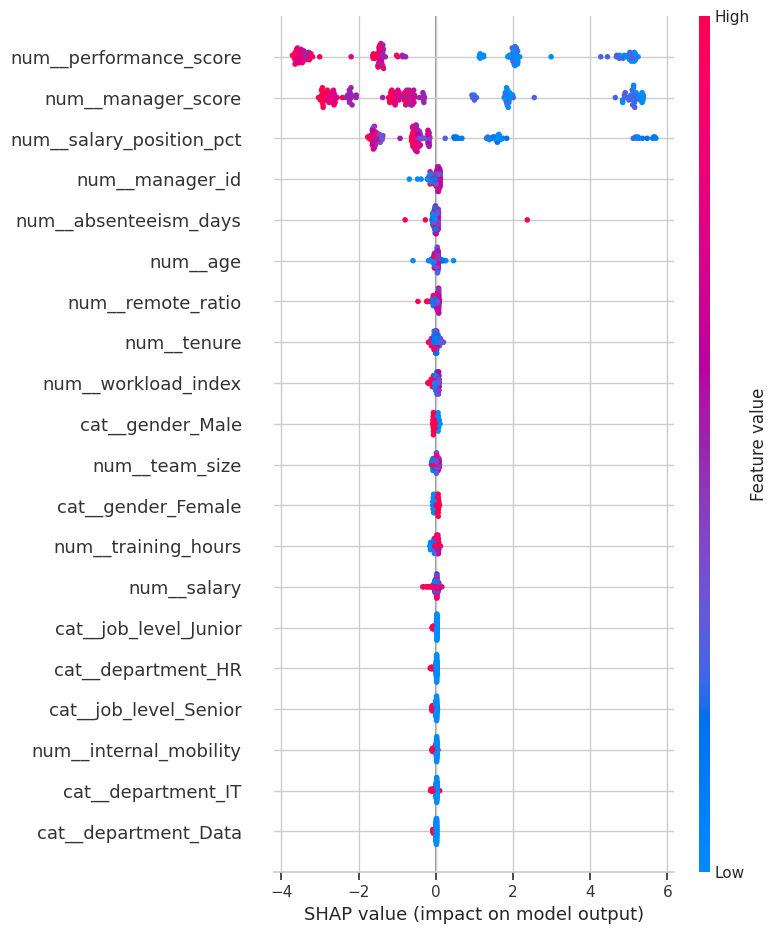

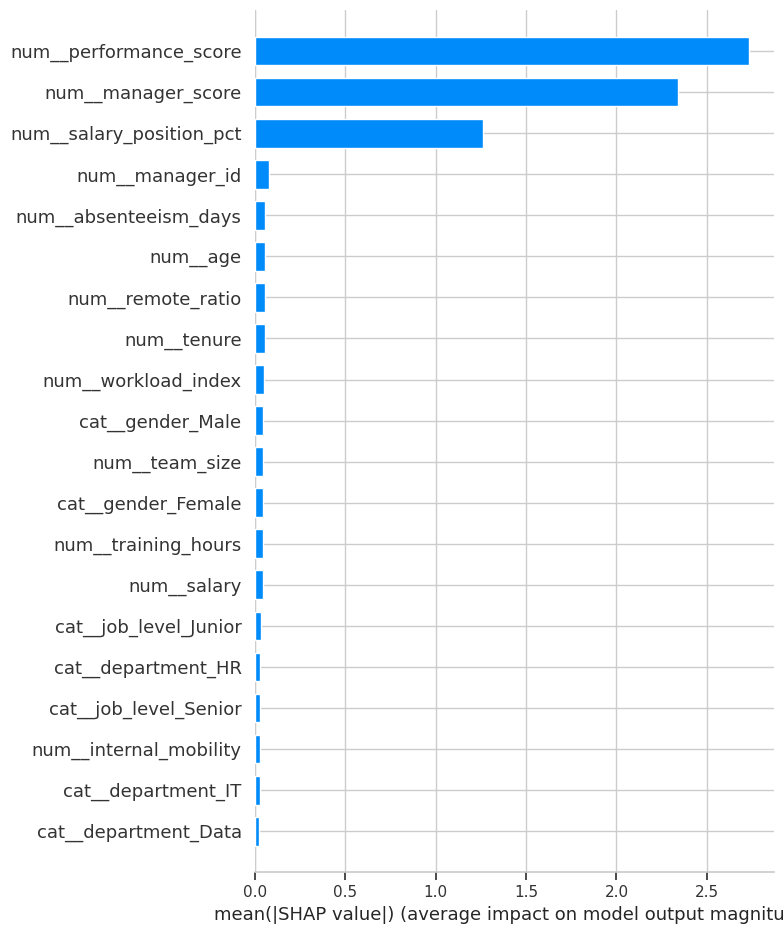

In [ ]:
# Interpretabilidad del Modelo con SHAP, vemos sólo CatBoost


# En este paso usamos SHAP para entender qué variables
# están influyendo más en las predicciones del modelo.
# Utilizamos CatBoost porque ha sido uno de los modelos
# con mejor rendimiento en la comparativa.

# 1. Reentrenar pipeline con CatBoost

cat_model = CatBoostClassifier(verbose=0, random_state=42)

cat_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", cat_model)
])

cat_pipe.fit(X_train, y_train)

# 2. Transformar datos

X_train_transformed = cat_pipe.named_steps["preprocessor"].transform(X_train)
X_test_transformed = cat_pipe.named_steps["preprocessor"].transform(X_test)

# Si sale en formato sparse, lo convertimos a array

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Obtener nombres de variables tras el preprocesado

feature_names = cat_pipe.named_steps["preprocessor"].get_feature_names_out()

# Pasamos a DataFrame para que SHAP se vea mejor
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 3. Calcular valores SHAP

explainer = shap.TreeExplainer(cat_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_shap)

# 4. Gráfico resumen global

shap.summary_plot(shap_values, X_test_shap)

# 5. Importancia media de variables

shap.summary_plot(shap_values, X_test_shap, plot_type="bar")

**## Interpretación del modelo con SHAP**

El **análisis con SHAP muestra que el modelo basa casi todas sus decisiones en pocas variables:** principalmente el **performance score, el manager score y, en menor medida, el salario relativo.**

El resto de variables (como edad, departamento o formación) tienen muy poco impacto en la predicción.

Esto confirma que **el modelo no está detectando patrones complejos, sino apoyándose en variables muy directamente relacionadas con el propio rendimiento.**

Por eso, aunque el modelo tiene resultados muy altos, **su utilidad en un entorno real es limitada**, ya que no aporta insights nuevos más allá de lo que ya indican esas variables.

## **Modelo final: Stacking para mejorar la detección de riesgo**

Tras analizar los modelos individuales, construimos un modelo final de *stacking* combinando Random Forest y XGBoost. **texto en negrita**

El **objetivo** no es solo mejorar métricas globales, sino r**educir errores críticos, especialmente los falsos negativos (casos en los que no detectamos empleados en riesgo).**

Este enfoque permite aprovechar las fortalezas de ambos modelos y buscar un mejor equilibrio entre precisión y capacidad de detección, algo clave en un contexto de People Analytics.

In [ ]:
# Definimos y entrenamos el stacking

# En este paso combinamos Random Forest y XGBoost en un modelo de stacking.

# Modelos base
estimators = [
    ("rf", RandomForestClassifier(random_state=42)),
    ("xgb", XGBClassifier(eval_metric="logloss", random_state=42))
]

# Meta-modelo final
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Pipeline completo
stacking_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stacking_model)
])

# Entrenamiento
stacking_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure',
                                                   'manager_id', 'salary',
                                                   'salary_position_pct',
                                                   'performance_score',
                                                   'manager_score',
                                                   'absenteeism_days',
                                                   'training_hours',
                                                   'promotion_last_2y',
                                                   'internal_mobility',
                                                   'workload_index'...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

📊 Métricas del Stacking:
Accuracy:  0.994
Precision: 1.000
Recall:    0.991
F1-score:  0.996
ROC-AUC:   0.999

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.99      1.00       113

    accuracy                           0.99       160
   macro avg       0.99      1.00      0.99       160
weighted avg       0.99      0.99      0.99       160



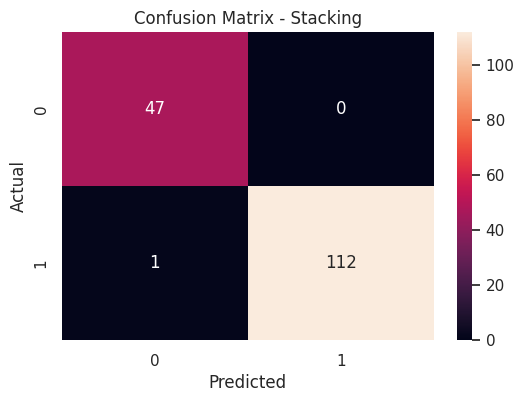

In [ ]:
# Métricas y matriz de confusión del Stacking

# Generamos predicciones y calculamos métricas
# para comparar el stacking con los modelos anteriores.

# Predicciones
y_pred_stack = stacking_pipe.predict(X_test)
y_proba_stack = stacking_pipe.predict_proba(X_test)[:, 1]

# Métricas
acc_stack = accuracy_score(y_test, y_pred_stack)
precision_stack = precision_score(y_test, y_pred_stack)
recall_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
roc_auc_stack = roc_auc_score(y_test, y_proba_stack)

print("📊 Métricas del Stacking:")
print(f"Accuracy:  {acc_stack:.3f}")
print(f"Precision: {precision_stack:.3f}")
print(f"Recall:    {recall_stack:.3f}")
print(f"F1-score:  {f1_stack:.3f}")
print(f"ROC-AUC:   {roc_auc_stack:.3f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_stack))

# Matriz de confusión
cm_stack = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_stack, annot=True, fmt="d")
plt.title("Confusion Matrix - Stacking")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Comparativa final (RF vs XGB vs STACKING)

# Filtramos solo los modelos que queremos comparar
selected_models = ["RandomForest", "XGBoost"]

filtered_results = results_employees[results_employees["Model"].isin(selected_models)].copy()

# Añadimos stacking
stacking_results = pd.DataFrame([{
    "Model": "Stacking_RF_XGB",
    "Accuracy": acc_stack,
    "Precision": precision_stack,
    "Recall": recall_stack,
    "F1_score": f1_stack,
    "ROC_AUC": roc_auc_stack
}])

# Unimos todo
final_results_df = pd.concat([filtered_results, stacking_results], ignore_index=True)

# Ordenamos por ROC_AUC
final_results_df = final_results_df.sort_values(by="ROC_AUC", ascending=False)

final_results_df

,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
0,RandomForest,0.98750,0.99115,0.99115,0.991150,0.999812
2,Stacking_RF_XGB,0.99375,1.00000,0.99115,0.995556,0.999247
1,XGBoost,0.99375,1.00000,0.99115,0.995556,0.996799


# **Conclusión**

Todos los modelos funcionan muy bien y detectan correctamente la mayoría de los casos de riesgo.

El **modelo final (stacking) mejora ligeramente los resultados en general**, pero **no consigue reducir los casos más críticos que se escapan (falsos negativos).**

Se predice una persona que produce menos, y permanece oculta.

Además, *el modelo se basa principalmente en variables directamente relacionadas con el rendimiento, por lo que su capacidad para generar nuevos insights es limitada.*

En en este caso, más que hacer modelos más complejos, el verdadero valor está en cómo se definen los datos y en cómo se utilizan estos resultados para tomar decisiones.

**En este caso, se pueden detectar a tiempo personas que pueden dar bajo rendimiento.**

**Veamos su posible efecto en negocio:**

In [ ]:
# Partimos del salario medio de los falsos negativos

avg_salary = false_negatives["salary"].mean()

# ------------------------------
# Supuestos
# ------------------------------

# Pérdida directa de productividad
productivity_loss = 0.30

# Duración del problema (en años)
duration = 1

# Multiplicador por impacto en equipo
team_multiplier = 1.5

# Coste de reemplazo (si aplica)
replacement_cost_pct = 0.25

# ------------------------------
# Escenarios
# ------------------------------

# 1. Escenario conservador (solo impacto directo)
impact_conservative = avg_salary * productivity_loss * duration

# 2. Escenario realista (incluye impacto en equipo)
impact_realistic = impact_conservative * team_multiplier

# 3. Escenario alto (incluye posible reemplazo)
impact_high = impact_realistic + (avg_salary * replacement_cost_pct)

# ------------------------------
# Resultados
# ------------------------------

print("💰 Impacto estimado por persona:")
print(f"Escenario conservador: €{impact_conservative:,.0f}")
print(f"Escenario realista:   €{impact_realistic:,.0f}")
print(f"Escenario alto:       €{impact_high:,.0f}")

# Si quieres impacto total (multiplicando por nº de falsos negativos)
num_fn = len(false_negatives)

print("\n💸 Impacto total:")
print(f"Escenario conservador: €{impact_conservative * num_fn:,.0f}")
print(f"Escenario realista:   €{impact_realistic * num_fn:,.0f}")
print(f"Escenario alto:       €{impact_high * num_fn:,.0f}")

💰 Impacto estimado por persona:
Escenario conservador: €22,478
Escenario realista:   €33,718
Escenario alto:       €52,450

💸 Impacto total:
Escenario conservador: €22,478
Escenario realista:   €33,718
Escenario alto:       €52,450


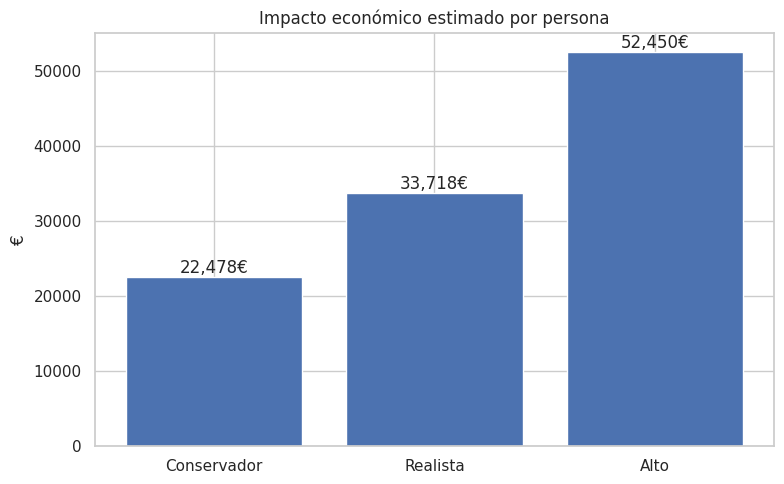

In [ ]:
# Visualizamos el impacto estimado por persona
# en tres escenarios: conservador, realista y alto.

labels = ["Conservador", "Realista", "Alto"]
values = [impact_conservative, impact_realistic, impact_high]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.title("Impacto económico estimado por persona")
plt.ylabel("€")

# Etiquetas sobre cada barra
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,.0f}€", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# **Impacto en negocio**

Detectar a tiempo a personas con bajo rendimiento **puede evitar pérdidas importantes.**

Aunque el impacto directo puede parecer limitado, al considerar el tiempo, **el efecto en el equipo y posibles costes de reemplazo, el impacto real puede superar los 50.000€ por persona.**

Esto refuerza la importancia de identificar estos casos de forma temprana para tomar decisiones y reducir su impacto en el negocio.